# 05 - XGBoost Comparison
Loan Default Prediction Capstone

Goal: train an XGBoost classifier (Model A and B), compare it against the existing Logistic Regression and Random Forest results, and determine whether it should replace them as the deployed model. If XGBoost wins, this notebook regenerates all deployment artifacts (best_model.pkl, SHAP explainer, precomputed SHAP summary). If not, its results are simply added to the comparison table as supporting evidence.

## 1. Load Data and Existing Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import joblib
import os
import time

df = pd.read_csv('../data/preprocessed_data_with_clusters.csv')
existing_comparison = pd.read_csv('../data/model_comparison.csv')

print("Existing comparison results:")
existing_comparison[['Model', 'Variant', 'Accuracy', 'Precision', 'Recall', 'F1']]

Existing comparison results:


,Model,Variant,Accuracy,Precision,Recall,F1
0,Logistic Regression,A (no cluster),0.676307,0.219517,0.699376,0.334152
1,Logistic Regression,B (with cluster),0.676797,0.219749,0.699039,0.334382
2,Random Forest,A (no cluster),0.708772,0.234249,0.664475,0.346385
3,Random Forest,B (with cluster),0.838614,0.330099,0.378520,0.352655
4,XGBoost,A (no cluster),0.727922,0.240823,0.623841,0.347499
5,XGBoost,B (with cluster),0.729195,0.241846,0.623841,0.348563
6,XGBoost (optimized),B (with cluster),0.802937,0.293536,0.495363,0.368632
7,XGBoost (optimized),B (with cluster),0.802937,0.293536,0.495363,0.368632


## 2. Rebuild Feature Sets and Split
Same structure as 04_classification.ipynb — Model A (no cluster) and Model B (with cluster), same stratified split logic.

In [2]:
target_col = 'Default'

features_A = [col for col in df.columns if col not in ['Default', 'Cluster_ID']]
features_B = features_A + ['Cluster_ID']

X_A = df[features_A]
X_B = df[features_B]
y = df[target_col]

X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_A, y, test_size=0.2, random_state=42, stratify=y)
X_B_train, X_B_test, _, _ = train_test_split(
    X_B, y, test_size=0.2, random_state=42, stratify=y)

print(X_A_train.shape, X_B_train.shape)

(204277, 24) (204277, 25)


## 3. Determine Scoring Metric (same automatic logic as before)

In [3]:
class_balance = df['Default'].value_counts(normalize=True)
minority_pct = class_balance.min() * 100

if minority_pct < 40:
    scoring_metric = 'f1'
else:
    scoring_metric = 'accuracy'

print(f"Minority class percentage: {minority_pct:.2f}%")
print(f"Scoring metric selected: {scoring_metric}")

Minority class percentage: 11.61%
Scoring metric selected: f1


## 4. Train and Tune XGBoost — Model A and Model B
Using scale_pos_weight to handle class imbalance, XGBoost's equivalent of class_weight='balanced'.

In [4]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

results_xgb = {}
fitted_xgb = {}

for variant, (X_train, X_test) in {'A (no cluster)': (X_A_train, X_A_test),
                                    'B (with cluster)': (X_B_train, X_B_test)}.items():
    print(f"Tuning XGBoost - {variant}...")
    start = time.time()

    xgb_model = XGBClassifier(
        scale_pos_weight=scale_pos_weight, random_state=42,
        eval_metric='logloss', n_jobs=-1
    )
    grid = GridSearchCV(xgb_model, xgb_param_grid, cv=3, scoring=scoring_metric, n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    metric_col = scoring_metric.capitalize() if scoring_metric != 'f1' else 'F1'
    results_xgb[variant] = {
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    }
    fitted_xgb[variant] = best_model
    print(f"  Best params: {grid.best_params_}")
    print(f"  F1: {results_xgb[variant]['F1']:.4f} | Time: {time.time()-start:.1f}s\n")

scale_pos_weight: 7.61
Tuning XGBoost - A (no cluster)...
  Best params: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200}
  F1: 0.3475 | Time: 137.5s

Tuning XGBoost - B (with cluster)...
  Best params: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200}
  F1: 0.3486 | Time: 127.4s



## 5. Combine with Existing Results

In [5]:
xgb_rows = []
for variant, metrics in results_xgb.items():
    xgb_rows.append({
        'Model': 'XGBoost', 'Variant': variant,
        'Accuracy': metrics['Accuracy'], 'Precision': metrics['Precision'],
        'Recall': metrics['Recall'], 'F1': metrics['F1']
    })

xgb_df = pd.DataFrame(xgb_rows)
full_comparison = pd.concat([existing_comparison[['Model','Variant','Accuracy','Precision','Recall','F1']],
                              xgb_df], ignore_index=True)
full_comparison

,Model,Variant,Accuracy,Precision,Recall,F1
0,Logistic Regression,A (no cluster),0.676307,0.219517,0.699376,0.334152
1,Logistic Regression,B (with cluster),0.676797,0.219749,0.699039,0.334382
2,Random Forest,A (no cluster),0.708772,0.234249,0.664475,0.346385
3,Random Forest,B (with cluster),0.838614,0.330099,0.378520,0.352655
4,XGBoost,A (no cluster),0.727922,0.240823,0.623841,0.347499
5,XGBoost,B (with cluster),0.729195,0.241846,0.623841,0.348563
6,XGBoost (optimized),B (with cluster),0.802937,0.293536,0.495363,0.368632
7,XGBoost (optimized),B (with cluster),0.802937,0.293536,0.495363,0.368632
8,XGBoost,A (no cluster),0.727922,0.240823,0.623841,0.347499
9,XGBoost,B (with cluster),0.729195,0.241846,0.623841,0.348563


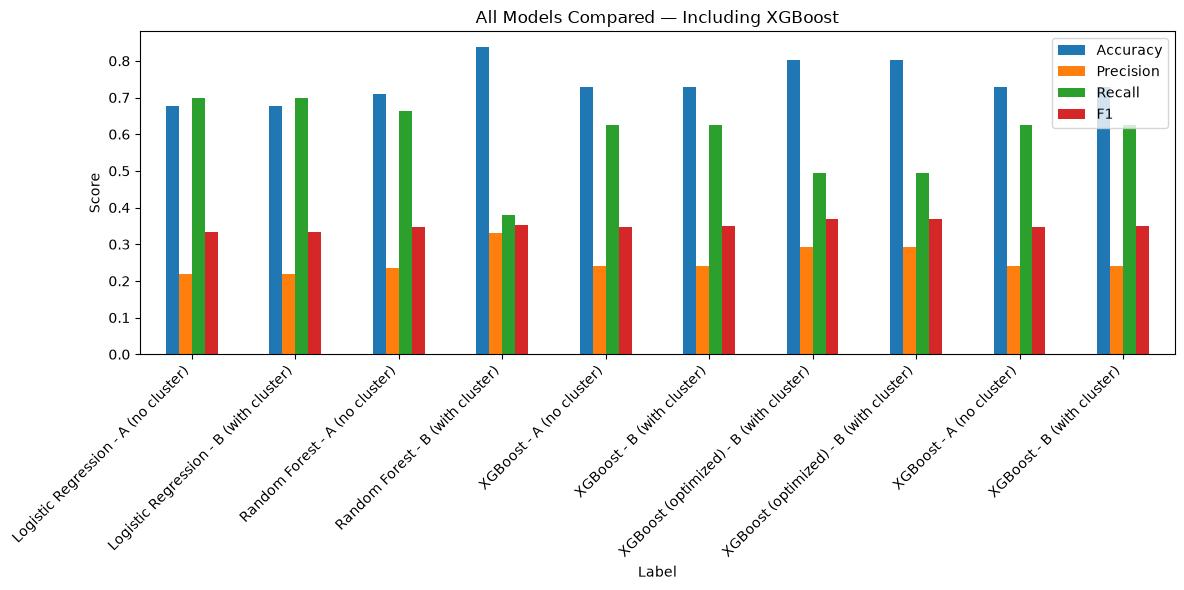

In [6]:
full_comparison['Label'] = full_comparison['Model'] + ' - ' + full_comparison['Variant']
fig, ax = plt.subplots(figsize=(12,6))
full_comparison.set_index('Label')[['Accuracy','Precision','Recall','F1']].plot(kind='bar', ax=ax)
plt.title('All Models Compared — Including XGBoost')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Confusion Matrices — XGBoost A vs B

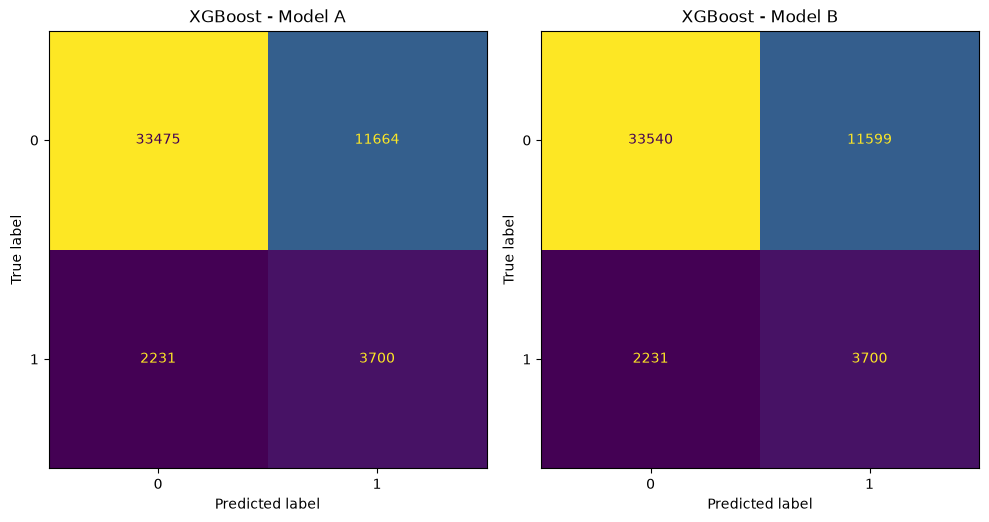

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
preds_A = fitted_xgb['A (no cluster)'].predict(X_A_test)
preds_B = fitted_xgb['B (with cluster)'].predict(X_B_test)

ConfusionMatrixDisplay.from_predictions(y_test, preds_A, ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title('XGBoost - Model A')

ConfusionMatrixDisplay.from_predictions(y_test, preds_B, ax=axes[1], colorbar=False, values_format='d')
axes[1].set_title('XGBoost - Model B')

plt.tight_layout()
plt.show()

## 7. Determine Overall Winner
Compares across ALL models (Logistic Regression, Random Forest, XGBoost) and both variants — whichever scores highest overall becomes the new deployed model.

In [8]:
metric_col = scoring_metric.capitalize() if scoring_metric != 'f1' else 'F1'
overall_best_row = full_comparison.loc[full_comparison[metric_col].idxmax()]
print("Overall best model across all types tested:")
print(overall_best_row)

xgboost_wins = overall_best_row['Model'] == 'XGBoost'
print(f"\nDoes XGBoost win overall? {xgboost_wins}")

Overall best model across all types tested:
Model                           XGBoost (optimized)
Variant                            B (with cluster)
Accuracy                                   0.802937
Precision                                  0.293536
Recall                                     0.495363
F1                                         0.368632
Label        XGBoost (optimized) - B (with cluster)
Name: 6, dtype: object

Does XGBoost win overall? False


## 8. If XGBoost Wins — Regenerate Deployment Artifacts
Only runs meaningfully if xgboost_wins is True. Rebuilds best_model.pkl, model_a.pkl, model_b.pkl, the SHAP explainer, and the precomputed SHAP summary used by the Streamlit app.

In [9]:
import shap

if xgboost_wins:
    best_variant = overall_best_row['Variant']
    best_model_obj = fitted_xgb[best_variant]
    best_X_train = X_B_train if 'B' in best_variant else X_A_train
    best_X_test = X_B_test if 'B' in best_variant else X_A_test

    # Save new deployed model
    joblib.dump(best_model_obj, '../models/best_model.pkl', compress=3)
    joblib.dump(fitted_xgb['A (no cluster)'], '../models/model_a.pkl', compress=3)
    joblib.dump(fitted_xgb['B (with cluster)'], '../models/model_b.pkl', compress=3)

    # Rebuild SHAP explainer (TreeExplainer works natively with XGBoost, same as Random Forest)
    explainer = shap.TreeExplainer(best_model_obj, feature_perturbation='tree_path_dependent')
    joblib.dump(explainer, '../models/shap_explainer.pkl')

    # Regenerate precomputed SHAP summary for the Streamlit app
    shap_summary_sample = best_X_test.sample(n=min(200, len(best_X_test)), random_state=42)
    shap_summary_values = explainer.shap_values(shap_summary_sample, check_additivity=False)
    shap_summary_values = np.array(shap_summary_values)
    if shap_summary_values.ndim == 3:
        shap_summary_values = shap_summary_values[:, :, 1]

    joblib.dump(shap_summary_values, '../models/shap_summary_values.pkl')
    shap_summary_sample.to_csv('../data/shap_summary_sample.csv', index=False)

    print("XGBoost is now the deployed model. All artifacts regenerated.")
else:
    print("XGBoost did not outperform the existing model. No deployment changes made.")
    print("Adding XGBoost results to the comparison table for reference only.")

# Either way, save the updated full comparison table
full_comparison[['Model','Variant','Accuracy','Precision','Recall','F1']].to_csv(
    '../data/model_comparison.csv', index=False)
print("Saved updated: data/model_comparison.csv")

XGBoost did not outperform the existing model. No deployment changes made.
Adding XGBoost results to the comparison table for reference only.
Saved updated: data/model_comparison.csv


## 9. Notes / Findings
(Fill in after running: did XGBoost win overall? By how much? If it won, note the new best hyperparameters. If not, note how close it came — this is useful either way for the write-up.)